# leafwaxtools Tutorial: Chain API class

Import the leafwaxtools Chain module/class and other necessary packages for this tutorial.

In [1]:
from leafwaxtools import Chain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cf8_data_df = pd.read_csv(r'../leafwaxtools/data/Thomas_CF8_2023.csv')

cf8_data_df.dropna(
    subset=[
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC21FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC23FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC25FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC27FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC29FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        # 'peakAreaC31FattyAcidMethylEster',
        # 'peakAreaC32FattyAcidMethylEster',
    ], inplace=True
)
cf8_data_df.reset_index(drop=True, inplace=True)

cf8_data_df



,CoreName,MidpointDepth,TopDepth,Thickness,SamplingID,UBlabID,SamplingNotesAboutSedimentology,AquaticMossMacrofossilAbundance,MassDrySediment,MassTotalLipidExtract,...,FAbrGDGTIIa',FAbrGDGTIIb,FAbrGDGTIIb',FAbrGDGTIIc,FAbrGDGTIIc',FAbrGDGTIa,FAbrGDGTIb,FAbrGDGTIc,ZhaoIWT,ageMedian
0,07CF8L4,0.25,0.0,0.5,EKT249,EKT249,no large aquatic moss macrofossils (none even ...,0,1.042,4.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7522.741
1,07CF8L4,0.75,0.5,0.5,EKT248,EKT248,no large aquatic moss macrofossils (none even ...,0,0.965,3.83,...,0.062,0.034,0.005,0.001,0.0,0.138,0.022,0.001,8.189462,7545.194
2,07CF8L4,1.25,1.0,0.5,EKT247,EKT247,no large aquatic moss macrofossils (none even ...,0,0.927,3.30,...,0.065,0.033,0.004,0.001,0.0,0.137,0.021,0.001,8.044775,7564.971
3,07CF8L4,1.75,1.5,0.5,EKT246,EKT246,no large aquatic moss macrofossils (none even ...,0,0.902,3.10,...,0.060,0.033,0.004,0.001,0.0,0.141,0.023,0.001,8.325403,7594.084
4,07CF8L4,2.25,2.0,0.5,EKT245,EKT245,no large aquatic moss macrofossils (none even ...,0,0.955,3.31,...,0.069,0.029,0.005,0.001,0.0,0.145,0.025,0.001,8.853391,7621.021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92,07CF8L4,68.25,68.0,0.5,EKT113,EKT113,lots of aquatic moss macrofossils (hard to sam...,6,0.790,NaN,...,0.053,0.007,0.000,0.000,0.0,0.110,0.006,0.000,5.267715,10837.010
93,07CF8L4,77.25,77.0,0.5,EKT095,EKT095,aquatic moss macrofossils,2,1.817,NaN,...,0.037,0.006,0.000,0.001,0.0,0.119,0.004,0.000,5.504847,11834.990
94,07CF8L4,77.75,77.5,0.5,EKT094,EKT094,aquatic moss macrofossils,2,1.167,NaN,...,0.039,0.005,0.000,0.000,0.0,0.111,0.003,0.000,5.064226,11894.530
95,07CF8L4,78.25,78.0,0.5,EKT093,EKT093,aquatic moss macrofossils,2,1.149,NaN,...,0.046,0.003,0.000,0.000,0.0,0.117,0.002,0.000,5.330160,11959.460


In [3]:
cf8_nacid_chain_df = cf8_data_df[
    [
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC21FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC23FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC25FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC27FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC29FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        # 'peakAreaC31FattyAcidMethylEster',
        # 'peakAreaC32FattyAcidMethylEster',
    ]
]

cf8_nacid_evenchain_df = cf8_nacid_chain_df[
    [
        'peakAreaC20FattyAcidMethylEster',
        'peakAreaC22FattyAcidMethylEster',
        'peakAreaC24FattyAcidMethylEster',
        'peakAreaC26FattyAcidMethylEster',
        'peakAreaC28FattyAcidMethylEster',
        'peakAreaC30FattyAcidMethylEster',
        # 'peakAreaC32FattyAcidMethylEster',
    ]
]

def get_chain_lengths(df_columns):
    chain_lengths_num = [None] * len(df_columns)
    chain_lengths_str = [None] * len(df_columns)
    for i in range(len(df_columns)):
        column_name = df_columns[i]
        chain_lengths_num[i] = int(column_name[9:11])
        chain_lengths_str[i] = "C" + str(chain_lengths_num[i])

    return chain_lengths_num, chain_lengths_str


cf8_chain_lengths, cf8_chain_lengths_str = get_chain_lengths(cf8_nacid_chain_df.columns)
cf8_evenchain_lengths, cf8_evenchain_lengths_str = get_chain_lengths(cf8_nacid_evenchain_df.columns)

print(cf8_chain_lengths)
print(cf8_chain_lengths_str)
print(cf8_evenchain_lengths)
print(cf8_evenchain_lengths_str)


[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
['C20', 'C21', 'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30']
[20, 22, 24, 26, 28, 30]
['C20', 'C22', 'C24', 'C26', 'C28', 'C30']


(0.0, 400.0)

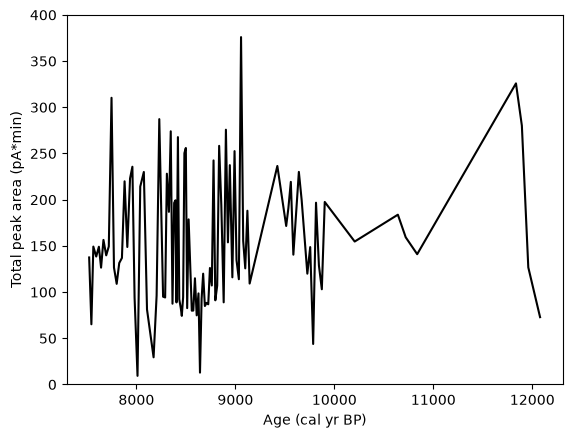

In [4]:
cf8_nacid_chain_total_conc = Chain(cf8_nacid_chain_df).total_conc()
cf8_nacid_chain_total_logconc = Chain(cf8_nacid_chain_df).total_conc(calculate_log=True)


fig, ax = plt.subplots()
ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_total_conc, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Total peak area (pA*min)")
ax.set_ylim([0,400])

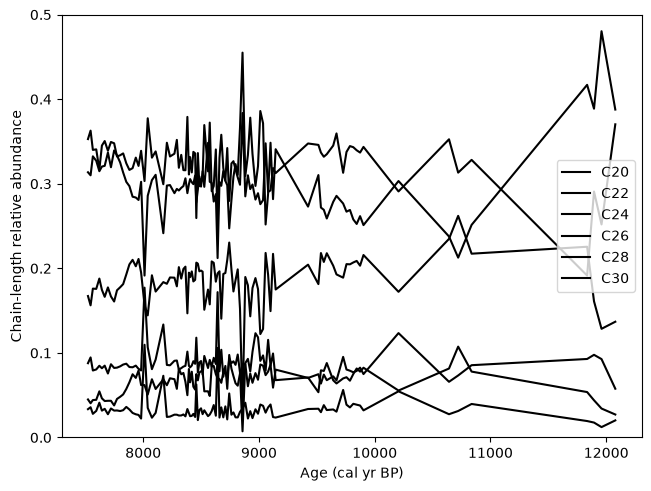

In [5]:
cf8_nacid_chain_relative_abd = Chain(cf8_nacid_evenchain_df).relative_abd()
cf8_nacid_chain_percent_abd = Chain(cf8_nacid_evenchain_df).relative_abd(calculate_percent=True)


colors = [
    'black',
    'black',
    'black',
    'black',
    'black',
    'black',
]

fig, ax = plt.subplots(layout='constrained')
for i in range(len(colors)):
    ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_relative_abd[:,i], color=colors[i], zorder=i, label=cf8_evenchain_lengths_str[i])
ax.set_ylim([0,0.5])
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Chain-length relative abundance")
ax.legend()

(24.5, 26.5)

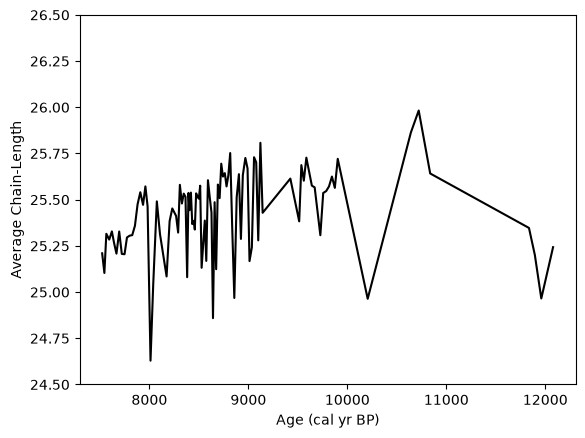

In [6]:
cf8_nacid_chain_acl = Chain(cf8_nacid_chain_df).acl(chain_lengths=cf8_chain_lengths)


fig, ax = plt.subplots()
ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_acl, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Average Chain-Length")
ax.set_ylim([24.5,26.5])

(2.0, 10.0)

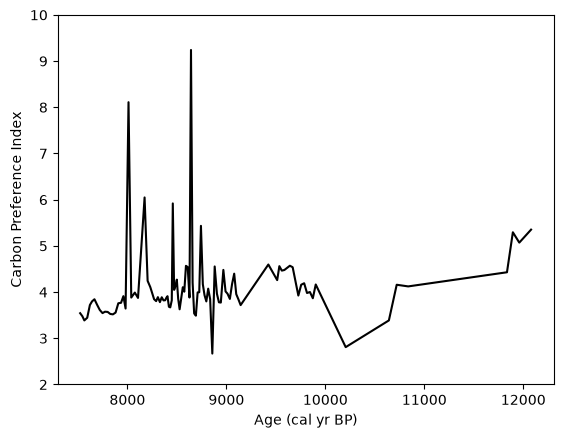

In [7]:
cf8_nacid_chain_cpi = Chain(cf8_nacid_chain_df).cpi(chain_lengths=cf8_chain_lengths)


fig, ax = plt.subplots()
ax.plot(cf8_data_df.ageMedian, cf8_nacid_chain_cpi, color='black')
ax.set_xlabel("Age (cal yr BP)")
ax.set_ylabel("Carbon Preference Index")
ax.set_ylim([2, 10])

In [ ]:
cf8_nacid_chain_correlation_rvals = Chain(cf8_nacid_chain_df).correlation_rvals()
cf8_nacid_chain_correlation_pvals = Chain(cf8_nacid_chain_df).correlation_pvals()

fig, axs = plt.subplots(2,2,layout='constrained')

ax = axs[0,0]

ax = axs[0,1]

fig.delaxes(axs[1,0])
fig.delaxes(axs[1,1])



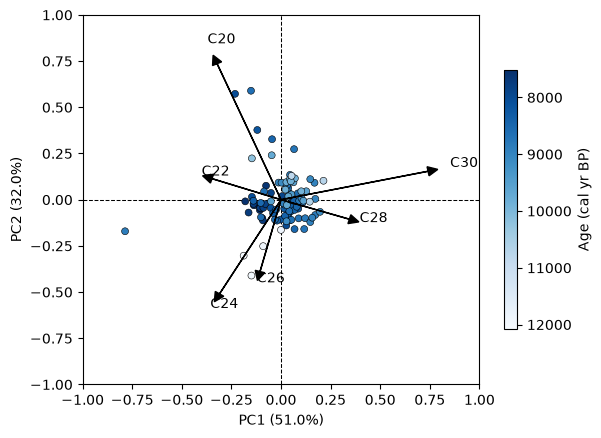

In [10]:
cf8_nacid_evenchain_pca = Chain(cf8_nacid_evenchain_df).pca(chain_lengths=cf8_evenchain_lengths_str)


fig, ax = plt.subplots()
for i, feature in enumerate(cf8_nacid_evenchain_pca["features"]):
    ax.arrow(
        0, 0, cf8_nacid_evenchain_pca["loadings"].iloc[i,0], cf8_nacid_evenchain_pca["loadings"].iloc[i,1],
        head_width=0.05, head_length=0.05, color='black', zorder=15
    )
    ax.text(
        cf8_nacid_evenchain_pca["loadings"].iloc[i,0] * 1.15, cf8_nacid_evenchain_pca["loadings"].iloc[i,1] * 1.15,
        str(feature), fontsize=10, zorder=15
    )
sns.scatterplot(
    ax=ax, x=cf8_nacid_evenchain_pca["scores_scaled"].PC1, y=cf8_nacid_evenchain_pca["scores_scaled"].PC2,
    s=25, hue=cf8_data_df.ageMedian, palette='Blues_r', edgecolors='black', zorder=10
)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.75, zorder=5)
ax.set_xlabel("PC1 (" + str(np.round(cf8_nacid_evenchain_pca["pca"].explained_variance_ratio_[0]*100, decimals=0)) + "%)")
ax.set_ylabel("PC2 (" + str(np.round(cf8_nacid_evenchain_pca["pca"].explained_variance_ratio_[1]*100, decimals=0)) + "%)")
ax.set_xlim([-1,1])
ax.set_ylim([-1,1])
ax.legend('', frameon=False)

norm = plt.Normalize(cf8_data_df['ageMedian'].min(), cf8_data_df['ageMedian'].max())
sm = plt.cm.ScalarMappable(cmap='Blues_r', norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, ax=ax,
    location='right', shrink=0.7, label="Age (cal yr BP)",
).ax.invert_yaxis()